In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')




In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


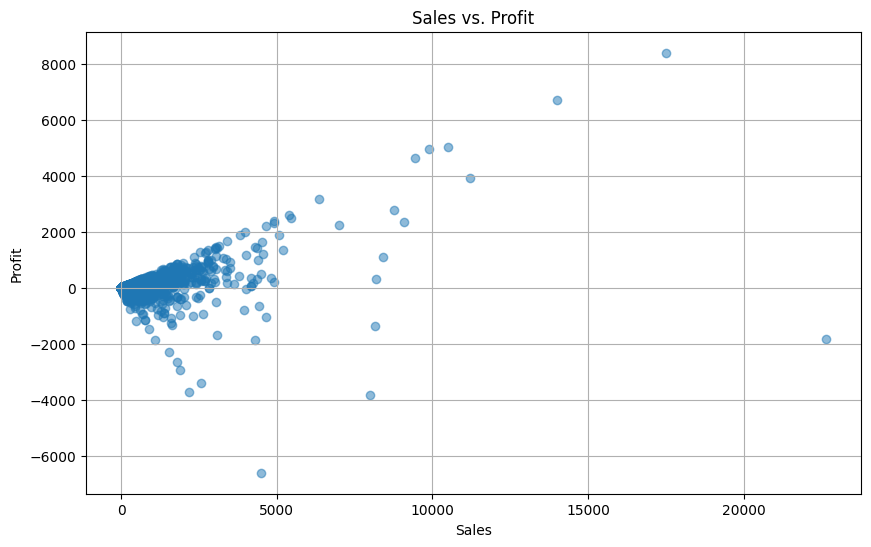

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs. Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
new_df = df.drop('Profit', axis='columns')
profit = df['Profit']

In [10]:
numeric_cols = new_df.select_dtypes(include=['number']).columns
x = new_df[numeric_cols]
y = profit
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(x_train,y_train)

Lasso(alpha=0.1)

In [14]:
train_pred = lasso.predict(x_train)
test_pred = lasso.predict(x_test)
train_r2 = r2_score(y_train,train_pred)
test_r2 = r2_score(y_test,test_pred)

In [15]:
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)
print("Training Accuracy (R2):", train_r2)

Training Accuracy (R2): 0.4342123650449893


In [16]:
print("Testing Accuracy (R2):", test_r2)

Testing Accuracy (R2): -0.7235803849940627


In [17]:
print("Training mse:", train_mse)
print("Testing mse:", test_mse)

Training mse: 31937.854638509412
Testing mse: 83568.01172979156


In [19]:
predicted_profit = lasso.predict([[1,42420,3500,2,0.0]])[0]
print(predicted_profit)

919.3327286428874


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
